In [1]:
%env XLA_PYTHON_CLIENT_PREALLOCATE=False

import os
import pickle

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from adaptive_smc.save_and_read_and_postprocess import acf2, correct_acf, acf


PKLs = []
PKL_titles = []
DIR = "./output/potential_1x3ExpmAx/tau2/"
for file in os.listdir(DIR):
    if file.endswith(".pkl") and "merge" not in file:
        PKLs.append(pickle.load(open(DIR + file, "rb")))
        PKL_titles.append(str(file))
n = len(PKLs)

env: XLA_PYTHON_CLIENT_PREALLOCATE=False


In [2]:
PKLs[0]['res'][0].shape

(10, 11, 2, 10, 101, 1)

In [3]:
idx_proposal = dict()
for i in range(n):
    proposal = PKLs[i]['config']['proposal']
    idx_proposal[proposal] = idx_proposal.get(proposal, []) + ([i])

mapping_labels = {'build_build_autoregressive_gaussian_proposal' : 'pCN',
'build_gaussian_rwmh_cov_proposal_gamma' : 'aRW',
'build_build_uncoupled_autoregressive_gaussian_proposal' : r"ARW"}

idx_proposal = {mapping_labels[proposal]: idx_proposal[proposal] for proposal in idx_proposal}

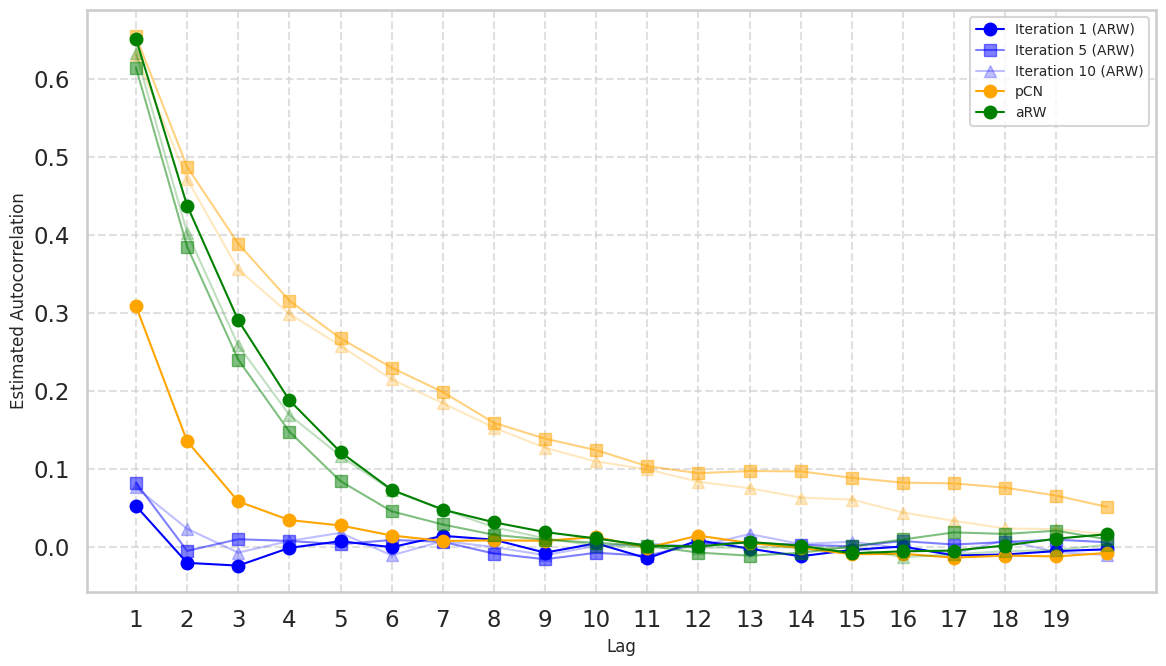

In [7]:
import matplotlib.pyplot as plt
import numpy as np

colors = ["blue", "orange", "green"]
alphas = [1., 0.5, 0.25]
component_idx = 2

plt.figure(figsize=(12, 7))

for p_idx, proposal in enumerate(idx_proposal):
    max_temp_idx = min(12, max([jnp.min(jnp.argwhere(PKLs[idx]['res'][6] == 1), axis=0)[1] for idx in idx_proposal[proposal]]))
    samples = jnp.concatenate([PKLs[idx]['res'][0][:,:,0, ..., component_idx, jnp.newaxis] for idx in idx_proposal[proposal]], axis=0)
    acfs = acf2(samples)[..., 0, 0]
    for idx_it, it in enumerate([1, 5, 10]):
        marker = ['o', 's', '^'][idx_it % 3]  # Use different markers for clarity
        plt.plot(np.arange(1, 21), acfs[:, it], 
                 marker=marker, 
                 label=f"Iteration {it} ({proposal})" if p_idx == 0 else f"{proposal}" if idx_it==0 else None,
                 color=colors[p_idx], 
                 alpha=alphas[idx_it],
                 linewidth=1.5)

# Beautify plot
plt.xlabel("Lag", fontsize=12)
plt.ylabel("Estimated Autocorrelation", fontsize=12)
#plt.title("Autocorrelation Function by Proposal and Iteration", fontsize=13)
plt.xticks(ticks=np.arange(1, 20, 1))  # Only integer x-ticks
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.savefig(DIR + "ACF.pdf", dpi=300)
plt.show()


In [5]:
for proposal in idx_proposal:
    for idx in idx_proposal[proposal]:
        if PKLs[idx]['res'][0] is None:
            print(idx)
            print(PKL_titles[idx])

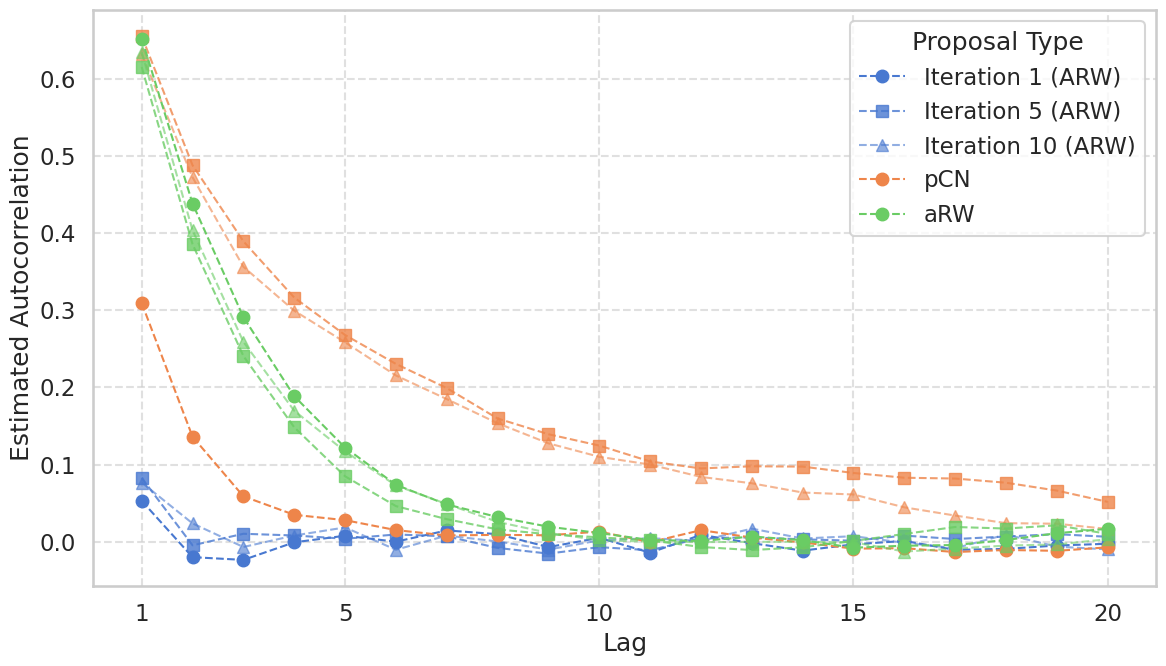

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

LAG = 20 # from 1 to 20 
xticks = np.arange(1, LAG+1)
display_x_ticks = np.concatenate([[1], np.arange(5, LAG+1, 5)])

# if there are too many dimension, we can restrict the samples to the marginal of the component of interest,
# and compute the acf for the marginal samplers
MARGINAL = False

# Match Seaborn style
sns.set(style='whitegrid', context='talk', palette='muted')

colors = sns.color_palette('muted')[:3]
alphas = [1., 0.8, 0.6]
component_idx = 0


plt.figure(figsize=(12, 7))

for p_idx, proposal in enumerate(idx_proposal):
    max_temp_idx = min(12, max([jnp.min(jnp.argwhere(PKLs[idx]['res'][6] == 1), axis=0)[1] for idx in idx_proposal[proposal]]))
    if MARGINAL:
        samples = jnp.concatenate([PKLs[idx]['res'][0][:,:,0, ..., component_idx, jnp.newaxis] for idx in idx_proposal[proposal]], axis=0) # tricks to avoid computing full acf since we are interested only in diagonal terms
        acfs = acf2(samples, max_order=LAG)[..., 0, 0]
    else:
        samples = jnp.concatenate([PKLs[idx]['res'][0][:,:,0] for idx in idx_proposal[proposal]], axis=0)
        acfs = acf2(samples, max_order=LAG)[..., component_idx, component_idx]
    for idx_it, it in enumerate([1, 5, 10]):
        marker = ['o', 's', '^'][idx_it % 3]
        label = f"Iteration {it} ({proposal})" if p_idx == 0 else f"{proposal}" if idx_it == 0 else None
        plt.plot(xticks, acfs[:, it], 
                 marker=marker, 
                 label=label,
                 color=colors[p_idx], 
                 alpha=alphas[idx_it],
                 linewidth=1.5,
                 linestyle="--")

# Beautify to match boxplot
plt.xlabel("Lag")
plt.ylabel("Estimated Autocorrelation")
plt.xticks(ticks=display_x_ticks)
plt.legend(title='Proposal Type', loc='upper right')

plt.grid(True, linestyle='--', alpha=0.6)


plt.tight_layout()
plt.savefig(DIR + "ACF.pdf", dpi=300)
plt.show()
